# Análisis Forense de Imágenes y Modelos Clásicos de Clasificación (Parte 2)

In [1]:
# 1. Importación de librerías
import os
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image, ImageStat

# Scikit-learn: Preprocesamiento y Modelos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Scikit-learn: Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)

# Configuración visual
sns.set_theme(style="whitegrid")
%matplotlib inline


## 2. Definición de Rutas y Muestreo Reproducible


In [2]:
DATASET_PATH = Path("./CASIA2")
AU_PATH = DATASET_PATH / "Au"
TP_PATH = DATASET_PATH / "Tp"

SAMPLE_SIZE = 300 # 300 imágenes por clase para mantener el análisis ágil
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

def get_sampled_files(folder_path, sample_size):
    if not folder_path.exists():
        print(f"Advertencia: La ruta {folder_path} no existe.")
        return []
    all_files = [f for f in folder_path.iterdir() if f.is_file() and not f.name.startswith('.')]
    if len(all_files) > sample_size:
        return random.sample(all_files, sample_size)
    return all_files

au_files = get_sampled_files(AU_PATH, SAMPLE_SIZE)
tp_files = get_sampled_files(TP_PATH, SAMPLE_SIZE)

print(f"Imágenes Auténticas (0): {len(au_files)}")
print(f"Imágenes Manipuladas (1): {len(tp_files)}")


Imágenes Auténticas (0): 300
Imágenes Manipuladas (1): 300


## 3. Extracción de Features (Básicas + Forenses)

In [3]:
def extract_forensic_features(filepath):
    """
    Lee una imagen y extrae un diccionario combinando características básicas y features forenses clásicas.
    """
    try:
        # ---- 1. Features Básicas (Metadatos) ----
        file_size_kb = filepath.stat().st_size / 1024
        
        with Image.open(filepath) as img:
            width, height = img.size
            aspect_ratio = width / height if height > 0 else 0
            
            img_rgb = img.convert('RGB')
            stats = ImageStat.Stat(img_rgb)
            mean_r, mean_g, mean_b = stats.mean
            std_r, std_g, std_b = stats.stddev
            brightness = 0.299*mean_r + 0.587*mean_g + 0.114*mean_b
        
        # ---- 2. Features Forenses (Análisis de Píxeles) ----
        # Leemos en escala de grises con OpenCV para análisis textural y de ruido
        img_cv = cv2.imread(str(filepath), cv2.IMREAD_GRAYSCALE)
        if img_cv is None:
            return None
        
        img_flt = img_cv.astype(np.float32)
        
        # A) Varianza del Laplaciano (Foco/Nitidez)
        # Imágenes con copy-paste a veces presentan discordancias en el desenfoque
        laplacian = cv2.Laplacian(img_cv, cv2.CV_64F)
        laplacian_var = laplacian.var()
        
        # B) Magnitud del Gradiente (Bordes / Sobel)
        sobelx = cv2.Sobel(img_flt, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(img_flt, cv2.CV_64F, 0, 1, ksize=3)
        gradient_mag = np.sqrt(sobelx**2 + sobely**2)
        grad_mean = gradient_mag.mean()
        grad_std = gradient_mag.std()
        
        # C) Análisis de Ruido Residual
        # Filtramos la imagen para "limpiar" el contenido de baja frecuencia y conservar el ruido de alta
        img_blurred = cv2.medianBlur(img_cv, 3).astype(np.float32)
        noise_residual = img_flt - img_blurred
        
        residual_mean = noise_residual.mean()
        residual_std = noise_residual.std()
        residual_energy = np.mean(noise_residual**2) # Energía promedio del residuo
        
        return {
            'width': width,
            'height': height,
            'aspect_ratio': aspect_ratio,
            'file_size_kb': file_size_kb,
            'brightness': brightness,
            'std_r': std_r, 'std_g': std_g, 'std_b': std_b,
            'laplacian_var': laplacian_var,
            'grad_mean': grad_mean,
            'grad_std': grad_std,
            'residual_mean': residual_mean,
            'residual_std': residual_std,
            'residual_energy': residual_energy
        }
    except Exception as e:
        return None

def process_dataset(files_list, label_val):
    data = []
    for f in files_list:
        feats = extract_forensic_features(f)
        if feats is not None:
            feats['label'] = label_val
            data.append(feats)
    return pd.DataFrame(data)

print("Procesando extracciones y métricas forenses...")
df_au = process_dataset(au_files, 0) # Au = 0
df_tp = process_dataset(tp_files, 1) # Tp = 1

df = pd.concat([df_au, df_tp], ignore_index=True)
print(f"Dataset construido exitosamente con {df.shape[0]} registros y {df.shape[1]-1} características.")


Procesando extracciones y métricas forenses...
Dataset construido exitosamente con 600 registros y 14 características.


## 4. División de datos y Escalado (Pipeline)


In [4]:
# Separar descriptores y vector objetivo
X = df.drop(columns=['label'])
y = df['label']

# Train / Test split estandarizado a 70% / 30%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_SEED, stratify=y
)

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 5. Entrenamiento y Refinamiento de Modelos 
Entrenaremos 3 modelos de Machine Learning clásico y guardaremos sus predicciones.
1. Regresión Logística: Eficiente interpretable como baseline.
2. Random Forest: Sensible a no-linealidades, muy poderoso con features tabulares.
3. SVM (RBF): Efectivo para encontrar límites n-dimensionales robustos.


In [5]:
# Definición de configuraciones y modelos
models = {
    "Logistic Regression": LogisticRegression(random_state=RANDOM_SEED, max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=150, max_depth=10, random_state=RANDOM_SEED),
    "SVM (RBF)": SVC(kernel='rbf', probability=True, random_state=RANDOM_SEED)
}

trained_models = {}
predictions = {}
predict_probs = {}

for name, model in models.items():
    print(f"Entrenando {name}...")
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    predictions[name] = model.predict(X_test_scaled)
    # Algunos modelos emiten probabilidad (SVM requiere 'probability=True')
    predict_probs[name] = model.predict_proba(X_test_scaled)[:, 1]
    
print("--- Entrenamiento Finalizado ---")


Entrenando Logistic Regression...
Entrenando Random Forest...
Entrenando SVM (RBF)...
--- Entrenamiento Finalizado ---


## 6. Evaluación Comparativa


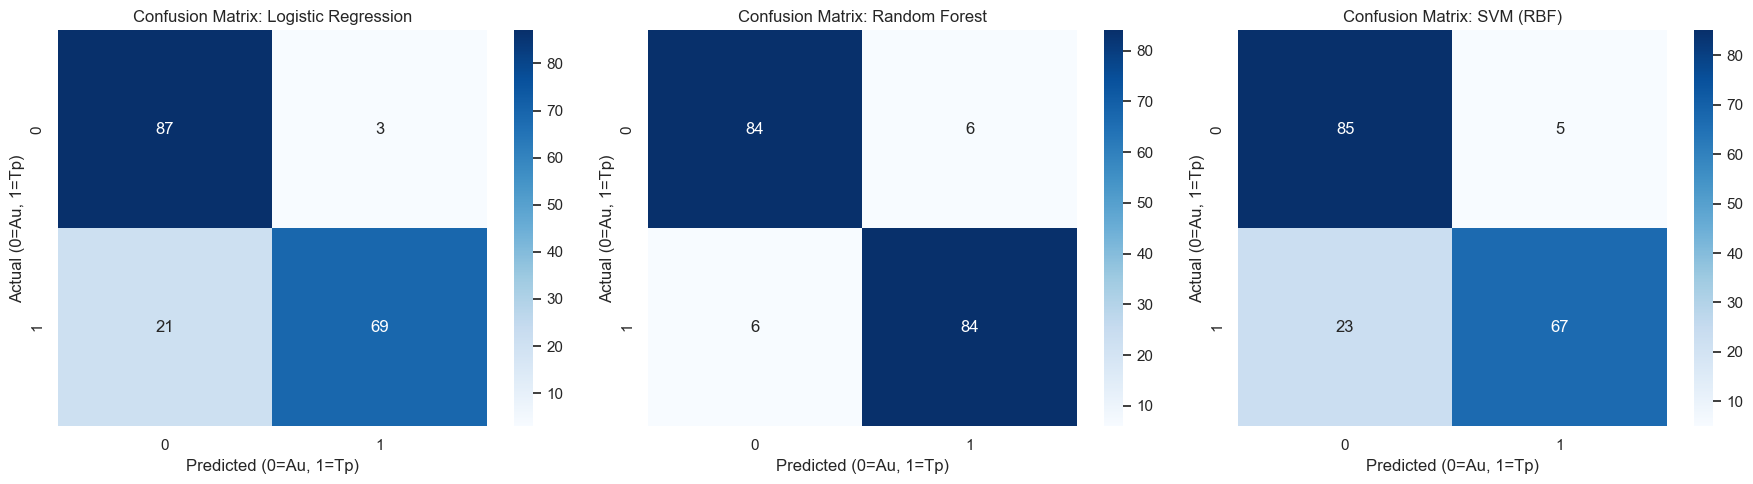

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8667,0.9583,0.7667,0.8519
1,Random Forest,0.9333,0.9333,0.9333,0.9333
2,SVM (RBF),0.8444,0.9306,0.7444,0.8272


In [6]:
results = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, y_pred) in enumerate(predictions.items()):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })
    
    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f"Confusion Matrix: {name}")
    axes[idx].set_xlabel('Predicted (0=Au, 1=Tp)')
    axes[idx].set_ylabel('Actual (0=Au, 1=Tp)')

plt.tight_layout()
plt.show()

# Tabla de resultados
df_results = pd.DataFrame(results).round(4)
display(df_results)


In [7]:
print("Ejemplo de Reporte de Clasificación Extendido (Random Forest):")
print(classification_report(y_test, predictions["Random Forest"], target_names=["Au (0)", "Tp (1)"]))


Ejemplo de Reporte de Clasificación Extendido (Random Forest):
              precision    recall  f1-score   support

      Au (0)       0.93      0.93      0.93        90
      Tp (1)       0.93      0.93      0.93        90

    accuracy                           0.93       180
   macro avg       0.93      0.93      0.93       180
weighted avg       0.93      0.93      0.93       180



## 7. Curva ROC y Área Bajo la Curva (AUC)


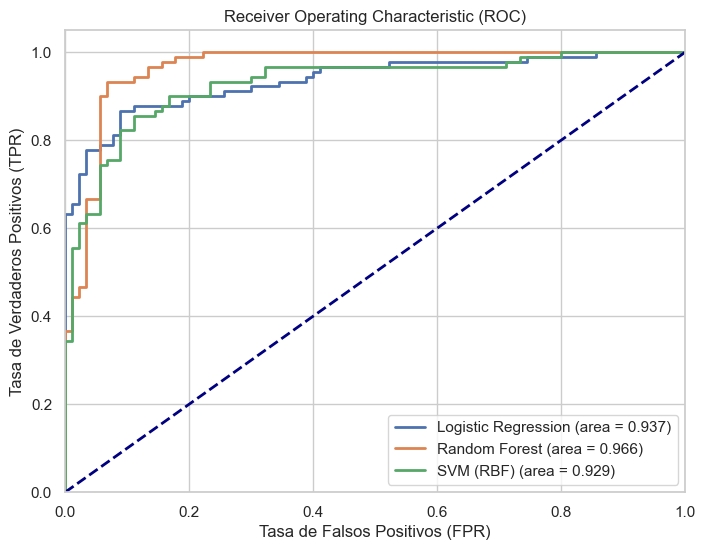

In [8]:
plt.figure(figsize=(8, 6))

for name, proba in predict_probs.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (area = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()
